# EDA e baseline

Base Kaggle **Bank Marketing** (`bank-additional-full.csv`). Objetivo: entender os dados,
checar qualidade, identificar data leakage e gerar a base processada para modelagem.

Rode a partir da raiz do repositório com o ambiente instalado (`pip install -e ".[dev]"`).

In [3]:
import sys
sys.path.insert(0, "../src")  # permite importar o pacote rodando de notebooks/

import pandas as pd
import matplotlib.pyplot as plt
from datathon_offerexp import data_loader as dl

In [4]:
# carrega a base original (caminho relativo a partir de notebooks/)
raw = dl.load_raw(dl.Path("../data/kaggle/bank-additional-full.csv"))
print("shape:", raw.shape)
raw.head()

shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Qualidade dos dados

In [5]:
print("Nulos (NaN):", int(raw.isna().sum().sum()))
print("Duplicadas:", int(raw.duplicated().sum()))
print("Conversão y=yes: {:.2f}%".format((raw['y'] == 'yes').mean() * 100))

# ausências vem como 'unknown', não como NaN
for c in raw.select_dtypes('object').columns:
    n = (raw[c] == 'unknown').sum()
    if n:
        print(f"  unknown em {c}: {n} ({n/len(raw)*100:.1f}%)")

Nulos (NaN): 0
Duplicadas: 12
Conversão y=yes: 11.27%
  unknown em job: 330 (0.8%)
  unknown em marital: 80 (0.2%)
  unknown em education: 1731 (4.2%)
  unknown em default: 8597 (20.9%)
  unknown em housing: 990 (2.4%)
  unknown em loan: 990 (2.4%)


## Sinais de conversão

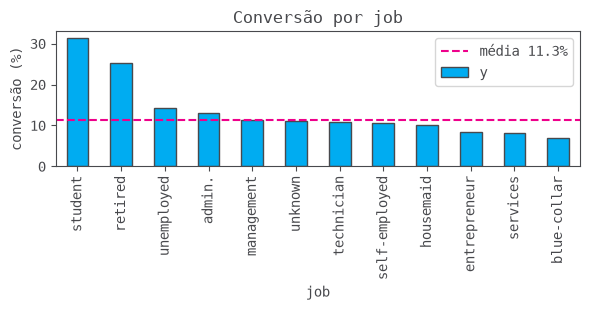

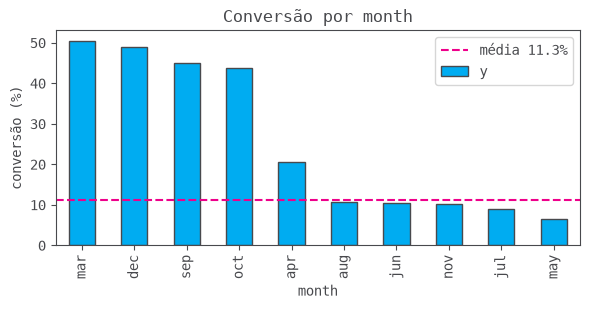

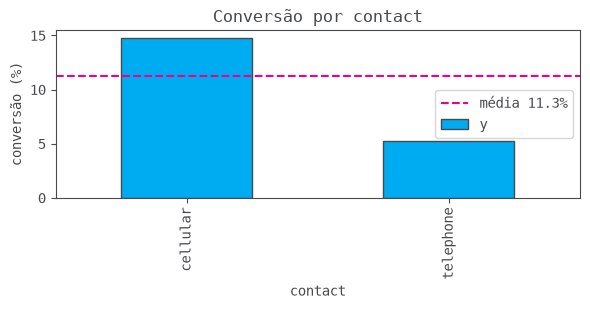

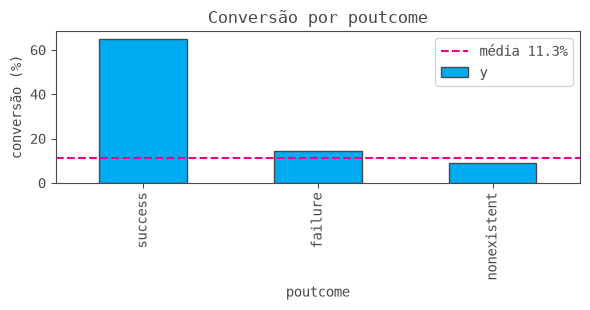

In [9]:
alvo = (raw['y'] == 'yes').astype(int)
media = alvo.mean() * 100

def conv_por(col):
    g = alvo.groupby(raw[col]).mean().mul(100).sort_values(ascending=False)
    ax = g.plot(kind='bar', color=AZUL, edgecolor=CINZA, figsize=(6, 3.2))
    ax.axhline(media, color=ROSA, ls='--', label=f'média {media:.1f}%')
    ax.set_title(f'Conversão por {col}'); ax.set_ylabel('conversão (%)')
    ax.legend(); plt.tight_layout(); plt.show()

for c in ['job', 'month', 'contact', 'poutcome']:
    conv_por(c)

## Base processada

Remove `duration` (para evitar data leakage), cria o alvo `subscribed` (0/1) e salva em Parquet.

In [12]:
df = dl.build_modeling_table(raw)
assert 'duration' not in df.columns, 'duration deveria ter sido removida'
assert 'subscribed' in df.columns
print('processada:', df.shape)
df.head()

processada: (41188, 20)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,subscribed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
